# Unsupervised learning ML

Scraper Mattilsynet data fra Twitter. 

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snscrape.modules.twitter as twitterScraper
import spacy
from spacy.lang.nb import Norwegian
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

In [11]:
scraper = twitterScraper.TwitterUserScraper("InfoMattilsynet", False)

Ser på 3 poster/tweets

In [18]:
for i, tweet in enumerate(scraper.get_items()):
    if i > 3:
        break
    print(f"{i} content {tweet.content}, dato {tweet.date.date()}")

0 content Vi har innført forbud mot å jakte på fugler i 15 kommuner i Rogaland. Jaktforbudet er innført for å hindre smitte til fjørfe og andre fugler i fangenskap. 
https://t.co/clYG2sTH5z, dato 2021-11-25
1 content https://t.co/9TN7z9Eln3, dato 2021-11-23
2 content Pressemelding: Mattilsynet har innført portforbud for fjørfe og andre fugler i fangenskap i Modum, Ringerike, Hole, Jevnaker, Lier, Gran og Søndre Land. https://t.co/O8fUQRuUK8, dato 2021-11-19
3 content I dag starter World Antimicrobial Awareness Week. Å bekjempe antibiotika-resistens er en viktig oppgave for oss i Mattilsynet også; I uka 18.-24. november sier vi derfor «Spread Awareness, Stop Resistance».
https://t.co/GfWFq6BkmD, dato 2021-11-18


In [23]:
dictionary = {'id':[], 'tekst':[], 'dato':[]}
for i, tweet in enumerate(scraper.get_items()):
    if i > 10000:
        break
    dictionary['id'].append(i)
    dictionary['tekst'].append(tweet.content)
    dictionary['dato'].append(str(tweet.date.date()))
print(dictionary)

{'id': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 22

In [26]:
data = pd.DataFrame.from_dict(dictionary)

In [27]:
data.to_csv("titusentwitringer.txt")

In [28]:
data.head()

,id,tekst,dato
0,0,Vi har innført forbud mot å jakte på fugler i ...,2021-11-25
1,1,https://t.co/9TN7z9Eln3,2021-11-23
2,2,Pressemelding: Mattilsynet har innført portfor...,2021-11-19
3,3,I dag starter World Antimicrobial Awareness We...,2021-11-18
4,4,Det er nå bekreftet fugleinfluensa i en verpeh...,2021-11-17


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 870 entries, 0 to 869
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      870 non-null    int64 
 1   tekst   870 non-null    object
 2   dato    870 non-null    object
dtypes: int64(1), object(2)
memory usage: 20.5+ KB


In [30]:
data['dato'] = pd.to_datetime(data['dato'])

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 870 entries, 0 to 869
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   id      870 non-null    int64         
 1   tekst   870 non-null    object        
 2   dato    870 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 20.5+ KB


### Tekst prosessering.

Tekst behandles i følgende trinn (ikke alle er nødvendig for det vi skal gjøre).
1. Tokenisering (Prosessen med å ta ut sammenhengende bokstaver og karakterer)
2. Stemming og Lemmatizing (sette ord i sin "opprinnelsesform")
3. Fjerne "stopp ord" og punkter (med punkter mener jeg også komma, kolon, etc...)

In [35]:
nlp = Norwegian()

Eksempler på stopp ord på norsk:

In [39]:
list(nlp.Defaults.stop_words)[:10]

['seg',
 'ligger',
 'du',
 'sier',
 'der',
 'da',
 'svært',
 'lørdag',
 'samtidig',
 'tirsdag']

Eksempler på token og lemma:

In [62]:
data['tekst'][0]

'Vi har innført forbud mot å jakte på fugler i 15 kommuner i Rogaland. Jaktforbudet er innført for å hindre smitte til fjørfe og andre fugler i fangenskap. \nhttps://t.co/clYG2sTH5z'

In [61]:
for token in nlp(data['tekst'][0]):
    print(token.text, token.lemma_, 
          token.shape_, token.is_alpha, token.is_stop)

Vi Vi Xx True True
har har xxx True True
innført innført xxxx True False
forbud forbud xxxx True False
mot mot xxx True True
å å x True True
jakte jakte xxxx True False
på på xx True True
fugler fugler xxxx True False
i i x True True
15 15 dd False False
kommuner kommuner xxxx True False
i i x True True
Rogaland Rogaland Xxxxx True False
. . . False False
Jaktforbudet Jaktforbudet Xxxxx True False
er er xx True True
innført innført xxxx True False
for for xxx True True
å å x True True
hindre hindre xxxx True False
smitte smitte xxxx True False
til til xxx True True
fjørfe fjørfe xxxx True False
og og xx True True
andre andre xxxx True True
fugler fugler xxxx True False
i i x True True
fangenskap fangenskap xxxx True False
. . . False False

 
 
 False False
https://t.co/clYG2sTH5z https://t.co/clYG2sTH5z xxxx://x.xx/xxXXdxXXdx False False


### Lager en tfidf matrise og ser på dimensjonene

In [42]:
n_features = 1000
vectorizer = TfidfVectorizer(max_features=n_features, stop_words=nlp.Defaults.stop_words)
X = vectorizer.fit_transform(data.tekst)

In [43]:
X.shape

(870, 1000)

#### Reduserer dimensjonene av matrisen (Med PCA). "Fjerne alle observasjoner som ikke har noe informasjon"

In [44]:
pca = PCA(n_components=0.95, random_state=0)
X_reduced= pca.fit_transform(X.toarray())
X_reduced.shape

(870, 510)

Ser på forskjellige mulige "klumping/clustering". Samler tekster med like ord-frekvens. Elbow plot for å finne en god optimal k

In [65]:
from scipy.spatial.distance import cdist
distortions = []
K = range(2, 30)
for k in K:
    k_means = KMeans(n_clusters=k, random_state=0).fit(X_reduced)
#     k_means.fit(X_reduced)
    distortions.append(sum(np.min(cdist(X_reduced, k_means.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0])

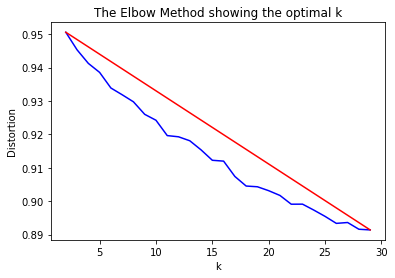

In [66]:
X_line = [K[0], K[-1]]
Y_line = [distortions[0], distortions[-1]]

# Plot the elbow
plt.plot(K, distortions, 'b-')
plt.plot(X_line, Y_line, 'r')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow metoden optimal k')
plt.show()

In [67]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=0)
y_pred = kmeans.fit_predict(X_reduced)
data['prediksjon'] = y_pred

Ut fra figuren over, velger jeg 10. Dette er for å minimere treningstiden og kompleksiteten i modellen.

### For å kunne visualisere alle tekstene, må den høy dimensjonale matrisen pojeseres på en 2-dim matrise

In [68]:
from sklearn.manifold import TSNE

tsne = TSNE(verbose=1, perplexity=50)  # Changed perplexity from 100 to 50 per FAQ
X_embedded = tsne.fit_transform(X.toarray())

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 870 samples in 0.039s...
[t-SNE] Computed neighbors for 870 samples in 0.707s...
[t-SNE] Computed conditional probabilities for sample 870 / 870
[t-SNE] Mean sigma: 0.461425
[t-SNE] KL divergence after 250 iterations with early exaggeration: 97.835739
[t-SNE] KL divergence after 1000 iterations: 2.027275


c:\users\micha\appdata\local\programs\python\python38\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


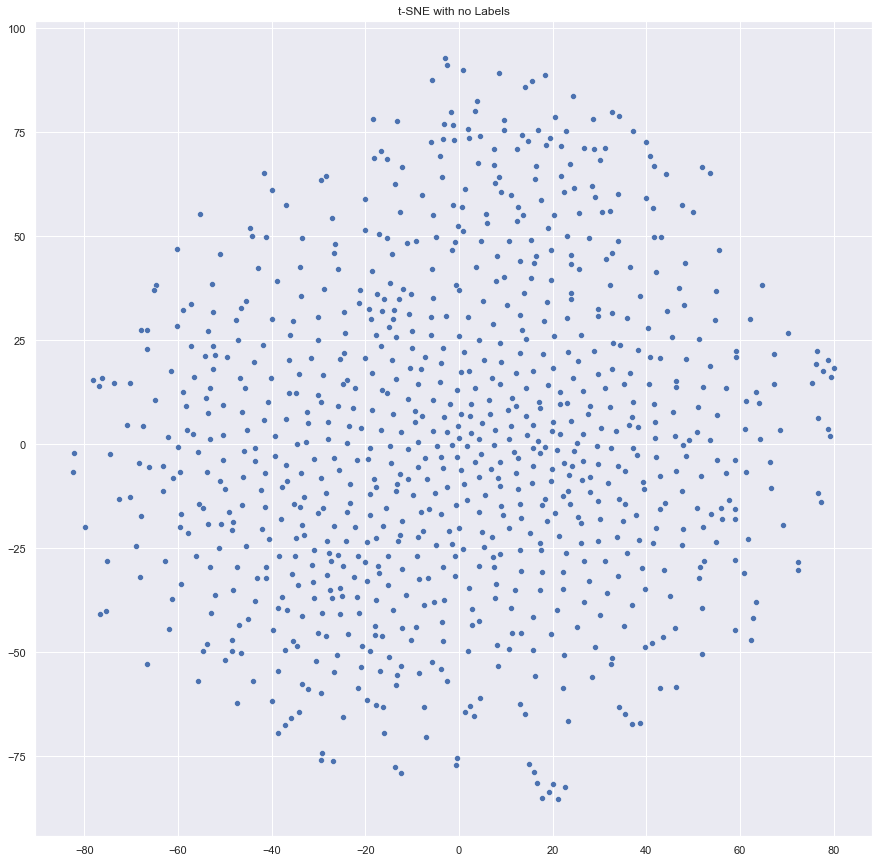

In [69]:
import seaborn as sns

# sns settings
sns.set(rc={'figure.figsize':(15,15)})

# colors
palette = sns.color_palette("bright", 1)

# plot
sns.scatterplot(X_embedded[:,0], X_embedded[:,1], palette=palette)
plt.title('t-SNE with no Labels')
plt.savefig("t-sne_covid19.png")
plt.show()

c:\users\micha\appdata\local\programs\python\python38\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


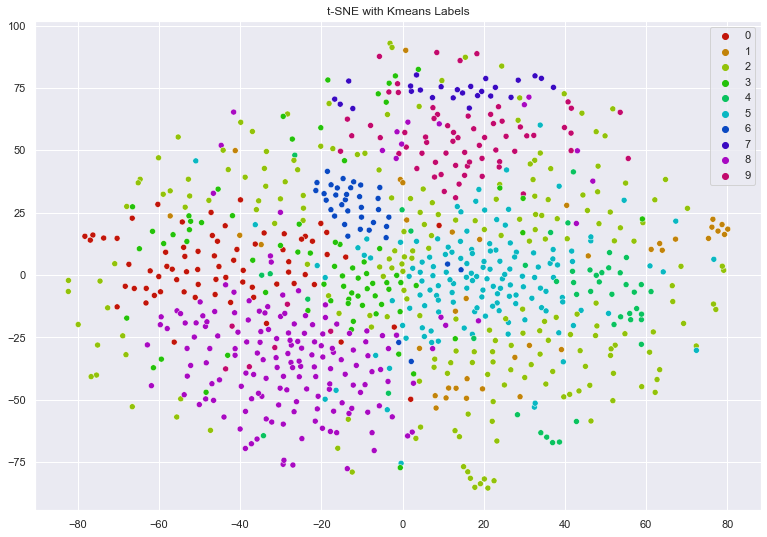

In [71]:
sns.set(rc={'figure.figsize':(13,9)})

# colors
palette = sns.hls_palette(10, l=.4, s=.9)

# plot
sns.scatterplot(X_embedded[:,0], X_embedded[:,1], hue=y_pred, legend='full', palette=palette)
plt.title('t-SNE with Kmeans Labels')
plt.savefig("improved_cluster_tsne.png")
plt.show()

## Samler clusterne og ser på de forskjellige tekstene som er i hver cluster.

In [97]:
vectorizer = TfidfVectorizer(max_df=0.5, max_features=1000, stop_words=nlp.Defaults.stop_words)

In [98]:
X = vectorizer.fit_transform(data.tekst)

In [106]:
# n_components = 500
svd = TruncatedSVD(n_components=100)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)

In [107]:
X = lsa.fit_transform(X)

In [108]:
k = 10
km = KMeans(n_clusters=k,
           init='k-means++',
           max_iter=100,
           n_init=1)
km.fit(X)

KMeans(max_iter=100, n_clusters=10, n_init=1)

In [109]:
sentroide_inverser = svd.inverse_transform(km.cluster_centers_)

In [110]:
sortert_sentroider = sentroide_inverser.argsort()[:, ::-1]

In [111]:
sortert_sentroider.shape

(10, 1000)

In [114]:
termer = vectorizer.get_feature_names()
for i in range(k):
    print(f"Cluster {i}: ", end="")
    for ind in sortert_sentroider[i, :5]:
        print(f"{termer[ind]}", end=" ")
    print()

Cluster 0: hunder bør begrense tilfeller minner 
Cluster 1: mattilsynet koronautbruddet vkmtryggmat bruk plantevernmidler 
Cluster 2: http mattilsynet dyr hund hos 
Cluster 3: mat koronavirus smitte via dyr 
Cluster 4: hei http deg info mattilsynet 
Cluster 5: skrantesjuke nordfjella k3bgt13gab tilfeller mistanke 
Cluster 6: dyrevelferd dyr hjemløsekatter http litteraturhuset 
Cluster 7: debattdyrevelferd tilsyn mattilsynet les matvarer 
Cluster 8: send svar no mail postmottak 
Cluster 9: ulovlig varer innførte mattryggheten forpliktet 


Prøver å lage en sentiment analyse.

In [2]:
from transformers import pipeline

In [3]:
classifier = pipeline("sentiment-analysis")

All model checkpoint layers were used when initializing TFDistilBertForSequenceClassification.

All the layers of TFDistilBertForSequenceClassification were initialized from the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


In [5]:
classifier("This is going to be great!")

[{'label': 'POSITIVE', 'score': 0.9998589754104614}]

In [4]:
classifier("Dette blir bra!")

[{'label': 'NEGATIVE', 'score': 0.8902578949928284}]